In [1]:
# %% Libraries
import os
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
import anndata as ad
import rapids_singlecell as rsc


# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'clustered'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'


# %% Load the unintegrated object
comb = sc.read_h5ad(CUR_OBJ_PATH)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'donor_colors', 'hvg', 'leiden_resolvi', 'log1p', 'nb_resolvi', 'nb_unint', 'pca', 'run_colors', 'sample_name_colors', 'slide_name_colors',

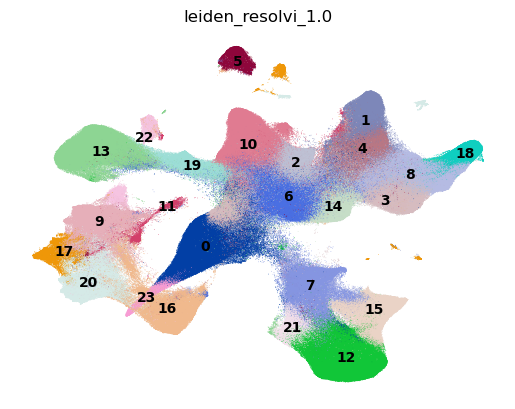

In [3]:
# check some markers

sc.pl.umap(
    comb,
    color=['leiden_resolvi_1.0'],
    frameon=False,
    ncols=2,
    layer='resolvi_normalized',
    vmax='p98',
    legend_loc='on data',
    size=1,
)

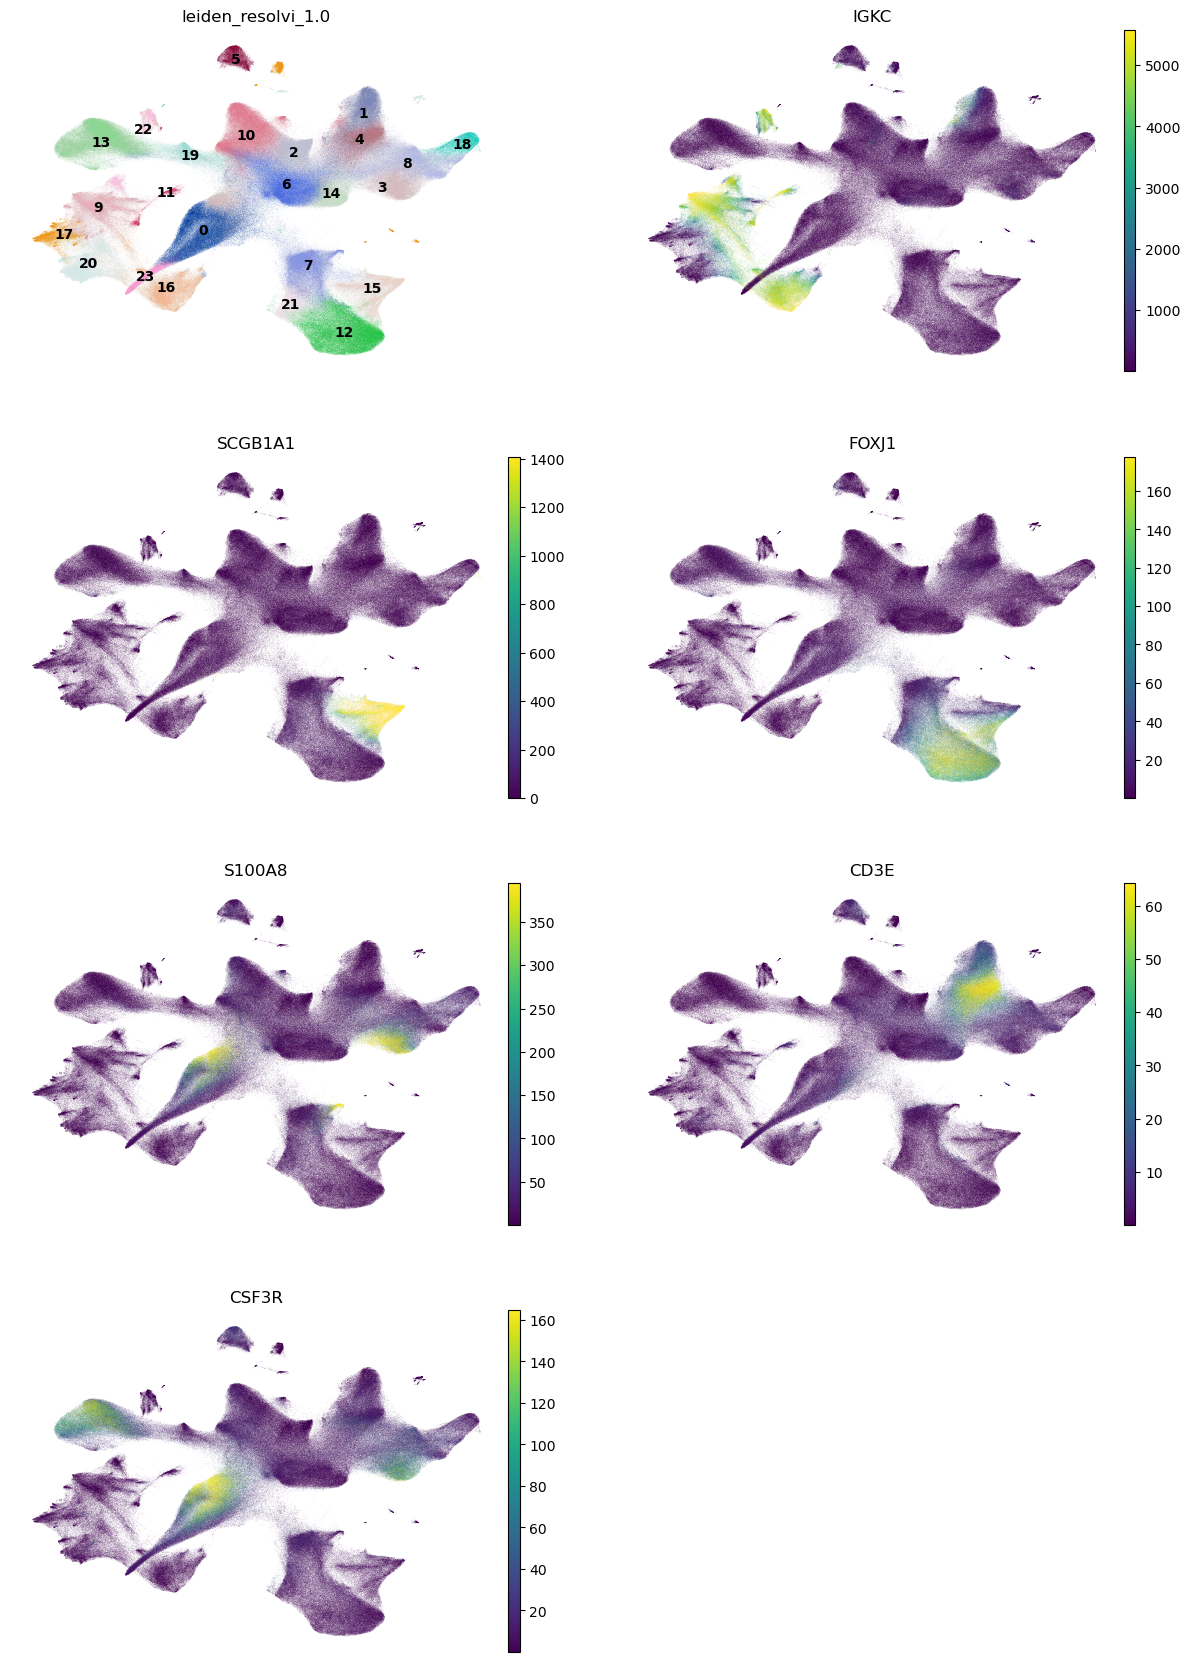

In [8]:
sc.pl.umap(
    comb,
    color=['leiden_resolvi_1.0','IGKC','SCGB1A1','FOXJ1','S100A8','CD3E','CSF3R'],
    frameon=False,
    ncols=2,
    layer='resolvi_normalized',
    vmax='p98',
    legend_loc='on data'
    
)

## ct_resolvi

In [5]:
leiden_resolvi_map = {
    # epithelial
    "7": "BC",
    "15": "SC",
    "12": "MCC",
    "21": "Gob",
    "19": "AT1",
    "13": "AT2",

    # Lymphoid
    "4": "T",
    "1": "B",
    "9": "PC_IgA", # plasma IGHA1
    "17": "PC_IgA", # plasma IGHA1
    "11": "PC_IgM", # plasma IGHM
    "20": "PC_IgG", # plasma IGHG1/2
    "16": "PC_IgG", # plasma IGHG1/2
    "22": "PC_IgAG", # plasma mixed cluster

    # Myeloid
    "3": "Neut",
    "5": "Mast",
    "18": "AlvMac",
    "8": "Mac",

    # Stroma
    "6": "Fib",
    "14": "actFib", # POSTN activated 
    "2": "SMC", # smooth muscle cells

    # Endothelial
    "10": "EC",

    # ambiguous
    "0": "Amb",
    "23": "Amb",
}

RESOLVI_CT_KEY = 'ct_resolvi'
RESOLVI_CLUSTERS_KEY = 'leiden_resolvi_1.0'
comb.obs['ct_resolvi'] = comb.obs[RESOLVI_CLUSTERS_KEY].map(leiden_resolvi_map).astype('category')

## Level 3 (ct_resolvi)

In [6]:
comb.obs['ann_lvl_3'] = comb.obs['ct_resolvi']

## Level 2

In [4]:
# rename classes 

map_lvl_2 = {
    
    # airway epithelium 
    'basal': 'airway_epithelium',
    'secretory': 'airway_epithelium',
    'ciliated': 'airway_epithelium',

    # alveolar epithelium
    'AT1': 'alveolar_epithelium',
    'AT2': 'alveolar_epithelium',

    # lymphoid
    'T': 'lymphoid',
    'B': 'lymphoid',
    'plasma': 'lymphoid',

    # myeloid
    'neutrophils': 'myeloid',
    'mast': 'myeloid',
    'macrophages': 'myeloid',
    'alveolar_macrophages': 'myeloid',

    # stromal
    'fibroblasts': 'stroma',
    'smooth_muscle': 'stroma',

    # endothelial
    'endothelial': 'endothelial',

    # cell debris
    'ambiguous': 'ambiguous',

}

comb.obs['ann_lvl_2'] = comb.obs['ct_resolvi'].map(map_lvl_2).astype('category')

## Level 1

In [5]:
# rename classes 

map_lvl_1 = {
    # epithelial 
    'airway_epithelium': 'epithelial',
    'alveolar_epithelium': 'epithelial',
    # immune
    'lymphoid': 'immune',
    'myeloid': 'immune',
    # stromal
    'stroma': 'stroma',
    # endothelial
    'endothelial': 'endothelial',
    # cell debris
    'cell_debris': 'cell_debris',
}

comb.obs['ann_lvl_1'] = comb.obs['ann_lvl_2'].map(map_lvl_1).astype('category')

## Plots side by side

[<Axes: title={'center': 'leiden_resolvi_1.0'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'ann_lvl_3'}, xlabel='UMAP1', ylabel='UMAP2'>]

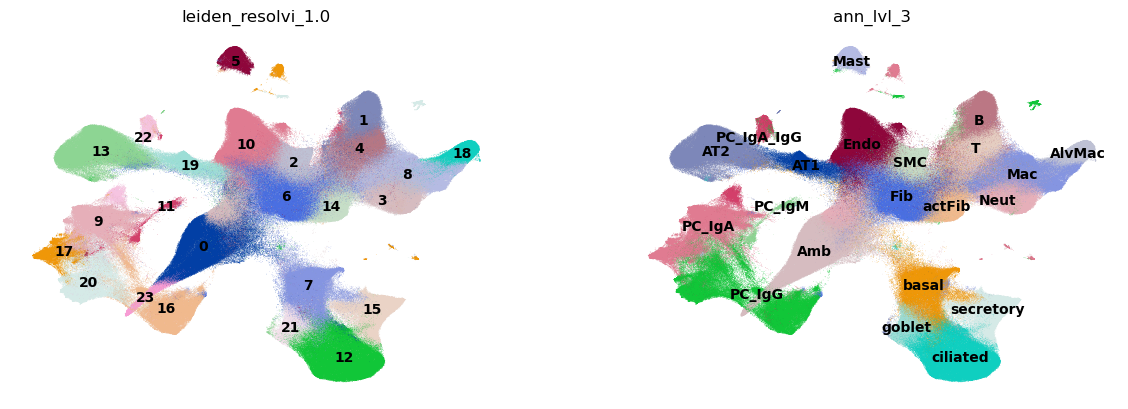

In [7]:
sc.pl.umap(
    comb,
    color=[RESOLVI_CLUSTERS_KEY,'ann_lvl_3'],
    size=0.5,
    frameon=False,
    legend_loc='on data',
    return_fig = False,
    show=False,
)

## Checking locations of `Amb`

Check locations

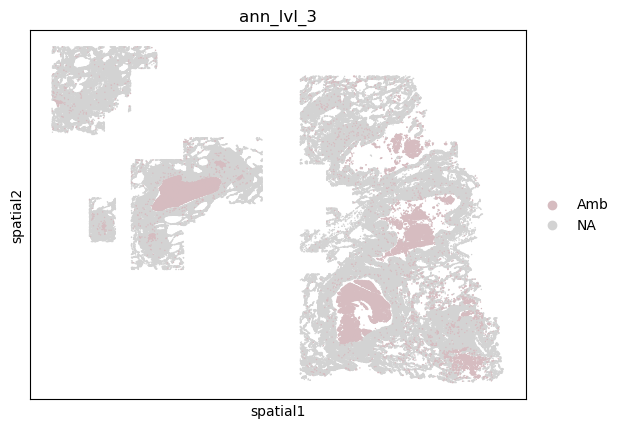

In [17]:
mask = comb.obs['sample_name'] == 'PWCF01_1'

sc.pl.embedding(
    comb[mask], 
    basis="spatial",
    color='ann_lvl_3',
    groups=['Amb'], # looks like sputum/low quality cells
    size=4
)

## Save Annotations

In [18]:
# save object
comb.write_h5ad(CUR_OBJ_PATH)

In [20]:
# Save metadata
metadata_df = comb.obs.copy()

meta_path = MAIN_DIR / "data" / "comb" / "meta" / "comb-meta.tsv"

# Create parent directories
meta_path.parent.mkdir(parents=True, exist_ok=True)

# Save TSV
metadata_df.to_csv(meta_path, sep="\t")